# Appendix - Code and Plots for Questions 4 and 5


## 4 - double pendulum

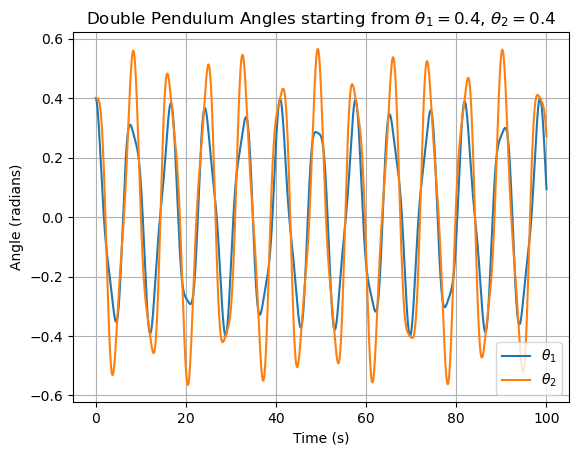

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
 
# State-space matrix for linearized double pendulum
A = np.array([[0, 0, 1, 0],
              [0, 0, 0, 1],
              [-2, 1, 0, 0],
              [2, -2, 0, 0]])

# Define the ODE function
def f(x, t):
    return A @ x

# Initial condition: small angles and zero velocities
x0 = np.array([0.4, 0.4, 0, 0])

# Time vector
t = np.linspace(0, 100, 5000)

# Solve the ODE
x = odeint(f, x0, t)

# Extract angles
theta1 = x[:, 0]
theta2 = x[:, 1]

# Plot angles
plt.figure()
plt.plot(t, theta1, label=r'$\theta_1$')
plt.plot(t, theta2, label=r'$\theta_2$')
plt.xlabel('Time (s)')
plt.ylabel('Angle (radians)')
plt.legend()
plt.grid(True)
plt.title(r'Double Pendulum Angles starting from $\theta_1 = 0.4$, $\theta_2 =0.4$')
plt.show()



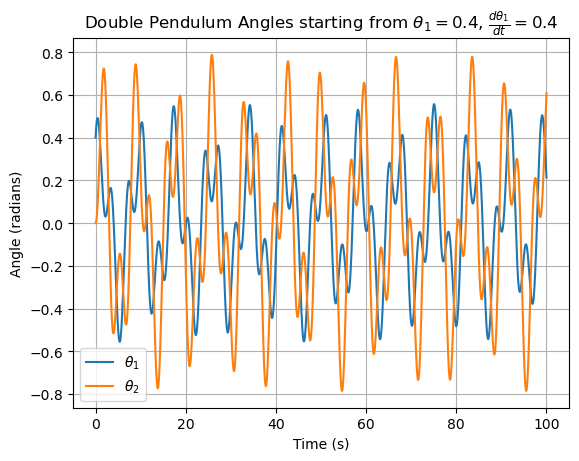

In [2]:

# Initial condition: small angles and zero velocities
x0 = np.array([0.4, 0, 0.4, 0])

# Time vector
t = np.linspace(0, 100, 5000)

# Solve the ODE
x = odeint(f, x0, t)

# Extract angles
theta1 = x[:, 0]
theta2 = x[:, 1]

# Plot angles
plt.figure()
plt.plot(t, theta1, label=r'$\theta_1$')
plt.plot(t, theta2, label=r'$\theta_2$')
plt.xlabel('Time (s)')
plt.ylabel('Angle (radians)')
plt.legend()
plt.grid(True)
plt.title(r'Double Pendulum Angles starting from $\theta_1 = 0.4$, $\frac{d \theta_1}{dt} =0.4$')
plt.show()



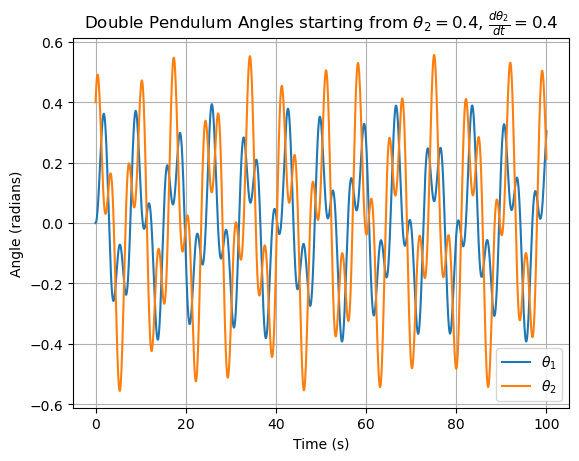

In [4]:

# Initial condition: small angles and zero velocities
x0 = np.array([0, 0.4, 0, 0.4])

# Time vector
t = np.linspace(0, 100, 5000)

# Solve the ODE
x = odeint(f, x0, t)

# Extract angles
theta1 = x[:, 0]
theta2 = x[:, 1]

# Plot angles
plt.figure()
plt.plot(t, theta1, label=r'$\theta_1$')
plt.plot(t, theta2, label=r'$\theta_2$')
plt.xlabel('Time (s)')
plt.ylabel('Angle (radians)')
plt.legend()
plt.grid(True)
plt.title(r'Double Pendulum Angles starting from $\theta_2 = 0.4$, $\frac{d \theta_2}{dt} =0.4$')
plt.show()



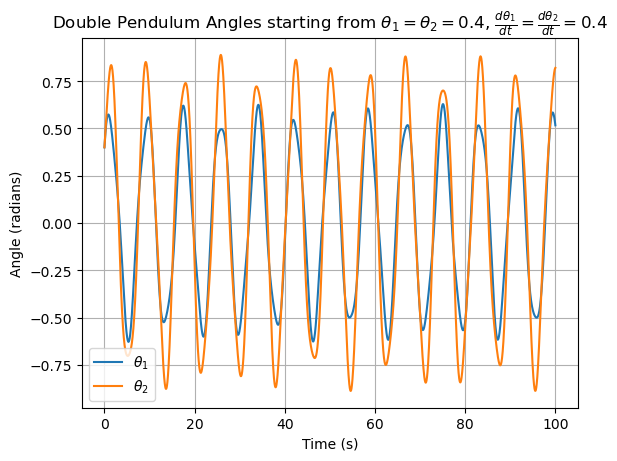

In [8]:

# Initial condition: small angles and zero velocities
x0 = np.array([0.4, 0.4, 0.4, 0.4])

# Time vector
t = np.linspace(0, 100, 5000)

# Solve the ODE
x = odeint(f, x0, t)

# Extract angles
theta1 = x[:, 0]
theta2 = x[:, 1]

# Plot angles
plt.figure()
plt.plot(t, theta1, label=r'$\theta_1$')
plt.plot(t, theta2, label=r'$\theta_2$')
plt.xlabel('Time (s)')
plt.ylabel('Angle (radians)')
plt.legend()
plt.grid(True)
plt.title(r'Double Pendulum Angles starting from $\theta_1 = \theta_2 = 0.4$, $\frac{d \theta_1}{dt} =\frac{d \theta_2}{dt} =0.4$')
plt.show()



## 5 - spring mass

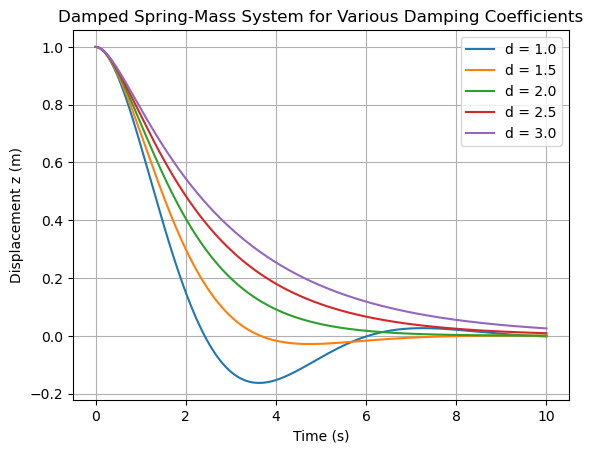

In [8]:
# System parameters
m = 1
k = 1
ds = np.linspace(1, 3, 5)  # damping coefficients to loop over

# Time vector
t = np.linspace(0, 10, 1000)

# Initial condition: z(0) = 1, z_dot(0) = 0
x0 = [1, 0]

plt.figure()
for d in ds:
    # State-space matrix A
    A = np.array([[0, 1],
                  [-k/m, -d/m]])
    
    # ODE function
    def f(x, t):
        return A @ x
    
    # Solve ODE
    x = odeint(f, x0, t)
    
    # x[:,0] = z, x[:,1] = z_dot
    plt.plot(t, x[:,0], label=f'd = {d:.1f}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement z (m)')
plt.title('Damped Spring-Mass System for Various Damping Coefficients')
plt.legend()
plt.grid(True)
plt.show()


At $d = 2 \sqrt{mk}$, $d = 2$ since $m = k = 1$. So, we are considering the green line. At critical damping, the system returns to equilibrium (displacement $z = 0$) as quickly as possible without any overshooting; as seen by the yellow line ($d = 1.5$), when the system is underdamped (damping less than the critical damping), there is quick return towards equilibrium, but the system overshoots and oscilates around equilibrium before settling. An overdamped system ($d \gt 2$, red and purple lines) will return to the equilibrium without oscillation but has a slower return to equilibrium than the critically damped system.

To understand why critical damping is ideal, consider a car's shock absorber. If the system is underdamped, the car bounces up and down (oscillates vertically) after hitting a bump. If the system is overdamped, the car slowly returns to its normal/equilibrium position, and may feel "heavy","sticky", or "sluggish." Critical damping provides the optimal balance, where the car quickly stabilizes without bouncing. Critical damping provides the fastest non-oscillatory return to a system's equilibrium.


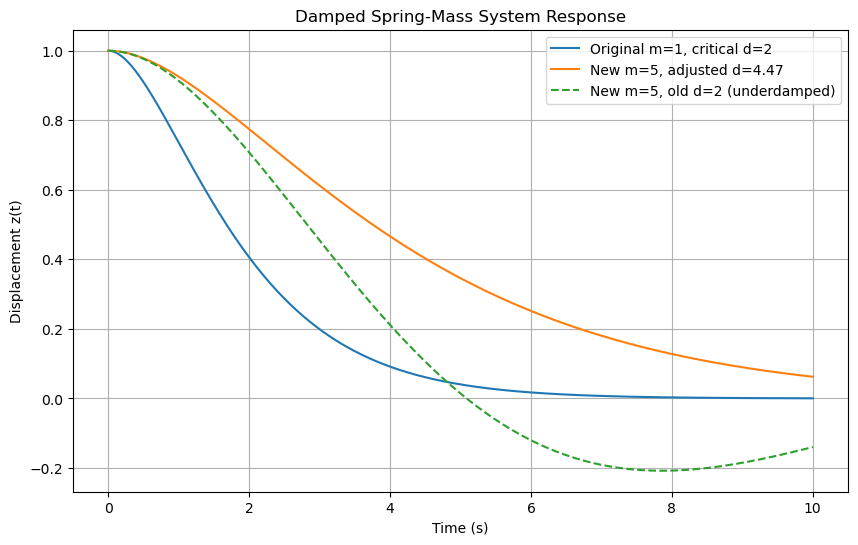

In [12]:

from scipy.integrate import solve_ivp

# System parameters
m_original = 1
k_original = 1
d_original = 2  # critical damping for m=1, k=1

m_new = 5  # new mass

# Compute new damping for critical damping
d_new = 2 * np.sqrt(m_new * k_original)  # keeping k the same

# State-space representation: x = [z, z_dot], dx/dt = [z_dot, z_ddot]
def damped_spring(t, x, m, d, k):
    z, z_dot = x
    z_ddot = -(d/m)*z_dot - (k/m)*z
    return [z_dot, z_ddot]

# Initial condition
x0 = [1, 0]  # start displaced 1 unit, zero velocity

# Time span
t_span = (0, 10)
t_eval = np.linspace(*t_span, 1000)

# Solve for original system
sol_orig = solve_ivp(damped_spring, t_span, x0, t_eval=t_eval, args=(m_original, d_original, k_original))

# Solve for new mass with adjusted damping
sol_new = solve_ivp(damped_spring, t_span, x0, t_eval=t_eval, args=(m_new, d_new, k_original))

# Solve for new mass without adjusting damping (underdamped)
sol_under = solve_ivp(damped_spring, t_span, x0, t_eval=t_eval, args=(m_new, d_original, k_original))

# Plot results
plt.figure(figsize=(10,6))
plt.plot(sol_orig.t, sol_orig.y[0], label='Original m=1, critical d=2')
plt.plot(sol_new.t, sol_new.y[0], label=f'New m=5, adjusted d={d_new:.2f}')
plt.plot(sol_under.t, sol_under.y[0], '--', label='New m=5, old d=2 (underdamped)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement z(t)')
plt.title('Damped Spring-Mass System Response')
plt.grid(True)
plt.legend()
plt.show()


$d_{crit} = 2 \sqrt{mk}$. For critical damping, $d_{new} = 2 \sqrt{5 k_{new}}$. 

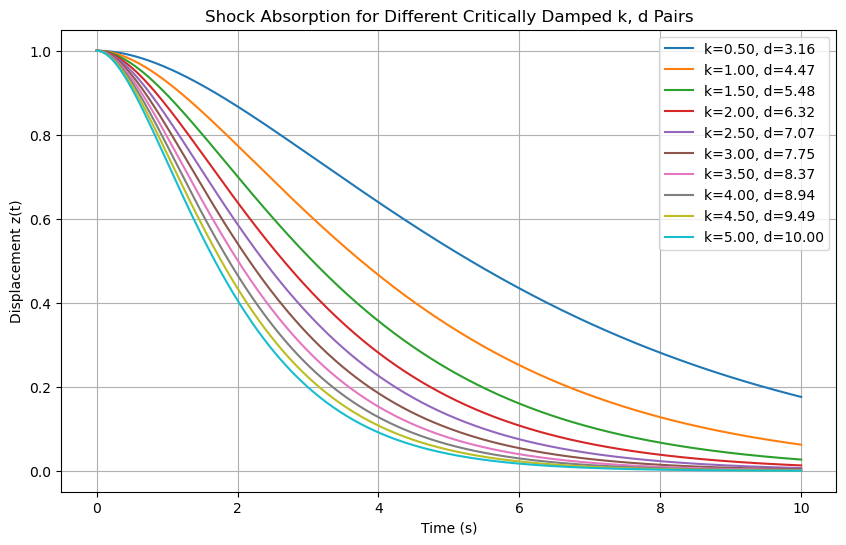

In [16]:


# Mass
m_new = 5

# Number of sample pairs
n = 10

# Range of spring constants
k_all = np.linspace(0.5, 5, 100)
d_all = 2 * np.sqrt(m_new * k_all)  # critical damping

# Pick n equally spaced indices
indices = np.linspace(0, len(k_all)-1, n, dtype=int)
k_samples = k_all[indices]
d_samples = d_all[indices]

# Time for simulation
t_span = (0, 10)
t_eval = np.linspace(*t_span, 1000)

# Initial displacement and velocity
z0 = [1, 0]  # z = 1, dz/dt = 0

plt.figure(figsize=(10,6))

for k_i, d_i in zip(k_samples, d_samples):
    # State-space system: x = [z, z_dot]
    def f(t, x):
        z, z_dot = x
        dzdt = z_dot
        dz_dotdt = -(d_i/m_new)*z_dot - (k_i/m_new)*z
        return [dzdt, dz_dotdt]
    
    sol = solve_ivp(f, t_span, z0, t_eval=t_eval)
    plt.plot(sol.t, sol.y[0], label=f'k={k_i:.2f}, d={d_i:.2f}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement z(t)')
plt.title('Shock Absorption for Different Critically Damped k, d Pairs')
plt.legend()
plt.grid(True)
plt.show()


As $k$ increases, $d$ also increases to maintain critical damping. Smaller spring constants $k$ with smaller damping coefficients $d$ lead to slower responses while larger $k,d$ pairs lead to stiffer springs/heavier damping and faster responses. All critically damped systems have no oscilation. The "best" system depends on the application: for comfort, choose a small $k$ and small $d$, but for fast response, choose large $k, d$ pairs. 